<a href="https://colab.research.google.com/github/Aidan4478D/ECE414/blob/main/ECE414_Assigment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Crop Classification from Satellite Imagery

- **Course:** ECE414 — Fundamentals of Remote Sensing and Earth Observation
- **Instructor:** Krishna Karra (krishna.karra@cooper.edu — Teams chat is quickest)
- **Assigned:** Wednesday, March 11, 2026
- **Due:** Sunday, March 29, 2026 (by midnight EST)

---

## The Scenario

You are a researcher in a remote sensing lab. Your lab director has secured a pilot contract to explore whether satellite imagery can be used to classify crop types across the U.S. Midwest — potentially months before official maps are released.

The USDA's [Cropland Data Layer (CDL)](https://www.nass.usda.gov/Research_and_Science/Cropland/SARS1a.php) is the gold standard for crop mapping in the Continental United States — a 30-meter annual map of crop types produced using Landsat and other satellite data. However, each year's CDL isn't released until well into the following year. If crop types could be predicted *in-season*, it would be transformative for crop monitoring, yield forecasting, agricultural policy, and environmental management.

Your lab director wants two things from you:

1. **A working prototype** — an end-to-end system that takes satellite imagery as input and produces a crop type classification map as output.
2. **A technical write-up** — a notebook documenting your methodology, experiments, results, and analysis. The write-up should be thorough enough that another researcher in the lab could understand and reproduce your work.

Your study region is **Iowa and Illinois**. The year you're working with is **2023** — this means you'll use 2023 Landsat imagery as your satellite data and the 2023 CDL as your ground truth for training and evaluation.

---

## Your Mission

Build an end-to-end crop classification system using Google Earth Engine and the Python API. Your system should:

- Identify the dominant crops grown in the study region
- Characterize how those crops behave spectrally across the growing season
- Train a classifier that predicts crop type from satellite imagery
- Deploy the classifier to new areas and assess how well it generalizes

The assignment is structured as four phases. Each phase builds on the previous one.

---

## Phase 1: Landscape Assessment

**Goal:** Determine which crops dominate the agricultural landscape in Iowa and Illinois.

**Deliverables:**
- A ranked table showing the most prevalent crops across Iowa and Illinois by area, computed from the 2023 CDL
- Identify the **top 5 most prevalent crops** — these will be your target classes for the rest of the assignment
- At least one visualization that supports your findings

**Things to think about:**
- The landscape contains far more than 5 crop types. When you deploy a classifier for only 5 crops, what happens to all the other pixels?
- How dominant are the top 5 compared to everything else?

---

## Phase 2: Crop Phenology Exploration

**Goal:** Understand how your target crops behave spectrally across the growing season, and use this understanding to inform your modeling approach.

**Deliverables:**
- Sampled pixel locations for each target crop class across the study region
- Time series plots showing the seasonal spectral behavior of each crop, with measures of central tendency and variability
- Written analysis connecting what you observe in the time series to what you expect for classification — which crops will be easy to separate? Which will be hard? When during the year are differences most pronounced?

**Things to think about:**
- How do you ensure your samples are representative of the full study region?
- What spectral index (or indices) best captures crop phenology, and why?
- How do you handle noisy or missing observations in the time series?

---

## Phase 3: Classification System

**Goal:** Design, train, and rigorously evaluate a pixel-level crop classification model for your top 5 crops.

**Deliverables:**
- A trained classifier that takes Landsat imagery features as input and predicts crop type
- A justification of your feature engineering choices — what inputs did you give the model, and why?
- Evaluation on a held-out test set including: confusion matrix, per-class precision, recall, and F1 score
- Error analysis — where does the model succeed and fail? Do the errors make sense given what you learned in Phase 2?
- Discussion of model iteration — what did you try, what worked, and what didn't?

**Important note on approach:** Start by building a classifier that uses a **full year's worth of Landsat imagery** (all of 2023). Getting a working end-to-end system with full-year data is the core requirement and will earn you full credit. Once you have that working, you can optionally explore whether your model can achieve reasonable performance with less data — for example, using only imagery up through July or August. This "in-season" prediction is the real-world motivation for this project and will earn bonus credit, but don't attempt it until you have a solid full-year baseline.

**Things to think about:**
- What features would allow a model to distinguish between your target crops?
- How should you split your data to get a trustworthy estimate of performance?
- If two crops are frequently confused, what does that tell you about your features or your class definitions?

---

## Phase 4: Deployment and Generalization

**Goal:** Apply your trained model to produce crop maps over full counties using **2024 imagery** and assess how well it generalizes — across both space and time.

Your model was trained on 2023 data from Iowa and Illinois. Now you'll deploy it to **2024** Landsat imagery and evaluate against the **2024 CDL**. This tests whether your model can generalize to a new year, not just new locations.

Deploy your full-year model first. If you built an in-season model as a bonus, you can deploy that too and compare.

**Deliverables:**
- Crop classification maps at 30m resolution for two counties, using **2024 Landsat imagery**:
  - **McLean County, Illinois** — one of the top corn- and soybean-producing counties in the entire U.S., located within your training region
  - **Renville County, Minnesota** — a major corn and soybean county outside your training region
- Side-by-side visual comparison of your maps against the **2024 CDL** for each county
- Analysis of generalization — how does performance change between the in-region and out-of-region county? Why? Does the shift from 2023 to 2024 affect performance?

**Things to think about:**
- What factors might cause a model trained in one region to perform differently in another?
- What factors might cause a model trained in one year to perform differently in another? (Think about weather, planting decisions, phenological shifts.)
- Do the spatial patterns in your map look reasonable, even where individual pixel predictions may be wrong?

---

## Deliverables Summary

Submit a single Jupyter notebook (.ipynb) that includes:

| Component | Description |
|-----------|-------------|
| Phase 1 | Crop prevalence analysis, class selection, and justification |
| Phase 2 | Sampling methodology, time series visualizations, phenological analysis |
| Phase 3 | Feature engineering, model training, evaluation metrics, error analysis |
| Phase 4 | County-level maps (McLean Co. IL, Renville Co. MN) using 2024 imagery, 2024 CDL comparison, generalization analysis |
| Throughout | Clean, documented code with markdown cells explaining your methodology and reasoning |

---

## Grading Rubric (100 points)

| Component | Points | What earns full credit |
|-----------|--------|----------------------|
| **Phase 1: Landscape Assessment** | 15 | Correct computation of crop areas; justified class selection; clean visualization |
| **Phase 2: Crop Phenology** | 25 | Sound sampling methodology; clear time series visualizations with variability; thoughtful phenological analysis; connection between observations and modeling strategy |
| **Phase 3: Classification** | 35 | Justified feature engineering; properly trained model; complete evaluation metrics (confusion matrix, precision, recall, F1); meaningful error analysis; evidence of iteration |
| **Phase 4: Deployment** | 15 | Maps for both counties; CDL comparison; substantive generalization analysis |
| **Code Quality & Documentation** | 10 | Readable, well-organized code; markdown cells that explain reasoning; reproducible workflow |

**Bonus (up to 10 points):** Exceptional work that goes beyond the core requirements. Examples include (but are not limited to): in-season prediction with limited temporal windows, advanced modeling techniques, temporal window analysis, or particularly insightful analysis.

### A note on grading philosophy

This assignment rewards **methodology and justification** over raw accuracy numbers. A well-documented system that achieves modest accuracy with clear analysis of why will score higher than a high-accuracy system with no explanation of the approach. Show your reasoning.

---

## Constraints and Resources

### Required
- **Platform:** Google Earth Engine with the Python API
- **Imagery:** Landsat. You can use others if you get something fully working with Landsat and want to add on.
- **Ground truth:** 2023 Cropland Data Layer (CDL)
- **Study region:** Iowa and Illinois
- **Evaluation:** Must include a held-out test set not seen during training

### Recommended resources
- [GEE Python API documentation](https://developers.google.com/earth-engine/apidocs)
- [geemap](https://geemap.org/) for visualization
- [CDL on GEE](https://developers.google.com/earth-engine/datasets/catalog/USDA_NASS_CDL) — `USDA/NASS/CDL`
- [Landsat on GEE](https://developers.google.com/earth-engine/datasets/catalog/landsat) — multiple collections available
- [TIGER/Counties](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_Counties) — for county boundaries
- Scikit-learn, TensorFlow, or other ML libraries may be used alongside GEE

---

## Tips and Advice

- **Get it working end-to-end before optimizing.** A complete pipeline with a simple model beats a sophisticated model that only covers half the assignment. Build your full-year baseline first, verify it works from sampling through deployment, and then iterate.
- **Start small, then scale up.** Test your workflows on a small area before running over the full study region. GEE computations over large areas can be slow and may time out if not handled carefully.
- **Store intermediate results.** Export computationally expensive intermediate products (FeatureCollections, Images) as GEE assets so you don't have to recompute them every time.
- **Documentation is not an afterthought.** Write your markdown explanations as you go, not at the end. Your future self (and your grader) will thank you.
- **Visualizations tell a story.** A well-crafted plot is worth a thousand words of explanation.
- **There are many valid approaches.** This assignment is deliberately open-ended. Two students can make very different design choices and both produce excellent work.
- **Ask questions early.** If you're stuck or unsure whether you're on the right track, reach out. I'm happy to provide guidance.


In [33]:
import geemap
import ee

ee.Authenticate()
ee.Initialize(project='ece414')

# Phase 1: Landscape Assessment
Goal: Determine which crops dominate the agricultural landscape in Iowa and Illinois.

Deliverables:

- A ranked table showing the most prevalent crops across Iowa and Illinois by area, computed from the 2023 CDL
- Identify the top 5 most prevalent crops — these will be your target classes for the rest of the assignment
- At least one visualization that supports your findings
Things to think about:

The landscape contains far more than 5 crop types. When you deploy a classifier for only 5 crops, what happens to all the other pixels?
How dominant are the top 5 compared to everything else?

In [34]:
# Study region
states = ee.FeatureCollection('TIGER/2018/States')
study_states = states.filter(
    ee.Filter.inList('NAME', ['Iowa', 'Illinois'])
)
study_region = study_states.geometry()

# Counties in Iowa + Illinois
counties = ee.FeatureCollection('TIGER/2018/Counties').filter(
    ee.Filter.inList('STATEFP', ['19', '17'])   # Iowa=19, Illinois=17
)

# 2023 CDL
cdl_2023 = (
    ee.ImageCollection('USDA/NASS/CDL')
    .filterDate('2023-01-01', '2024-01-01')
    .first()
)

cropland = cdl_2023.select('cropland')

# Area band in hectares
area_ha = ee.Image.pixelArea().divide(10000).rename('area_ha')

# Value band first, grouping band second
area_image = area_ha.addBands(cropland.rename('class'))

# Reduce by county
county_stats = area_image.reduceRegions(
    collection=counties,
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    scale=30,
    tileScale=4
)

# Keep only useful columns to reduce export size
county_stats_slim = county_stats.map(
    lambda f: ee.Feature(
        None,
        {
            'STATEFP': f.get('STATEFP'),
            'COUNTYFP': f.get('COUNTYFP'),
            'NAME': f.get('NAME'),
            'groups': f.get('groups')
        }
    )
)

# Export to Google Drive
# task = ee.batch.Export.table.toDrive(
#     collection=county_stats_slim,
#     description='cdl_2023_ia_il_county_crop_area',
#     folder='datasets/ece414_remote_sensing/EarthEngineExports/',
#     fileNamePrefix='cdl_2023_ia_il_county_crop_area',
#     fileFormat='CSV'
# )

# task.start()
print('Exported to drive.')

Exported to drive.


In [35]:
# Read exported CSV and aggregate in pandas
import pandas as pd
import ast

csv_path = '/content/drive/MyDrive/datasets/ece414_remote_sensing/EarthEngineExports/cdl_2023_ia_il_county_crop_area.csv'

county_df = pd.read_csv(csv_path)
county_df.head()

# print(len(county_df))

,system:index,COUNTYFP,NAME,STATEFP,groups,.geo
0,00000000000000000003,121,Marion,17,"[{class=1, sum=34023.58200408273}, {class=4, s...","{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000004,5,Bond,17,"[{class=1, sum=28720.891630543283}, {class=4, ...","{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000005,83,Jersey,17,"[{class=1, sum=23497.09697383551}, {class=4, s...","{""type"":""MultiPoint"",""coordinates"":[]}"
3,00000000000000000006,163,St. Clair,17,"[{class=1, sum=37121.95116851194}, {class=3, s...","{""type"":""MultiPoint"",""coordinates"":[]}"
4,00000000000000000007,27,Clinton,17,"[{class=1, sum=38571.22742320738}, {class=4, s...","{""type"":""MultiPoint"",""coordinates"":[]}"


In [36]:
# Expand the 'groups' column into long format
import re

rows = []
pattern = re.compile(r'\{class=([0-9]+), sum=([0-9eE+\-.]+)\}')

for _, row in county_df.iterrows():
    county_name = row['NAME']
    statefp = row['STATEFP']
    countyfp = row['COUNTYFP']
    groups = row['groups']

    if pd.isna(groups):
        continue

    matches = pattern.findall(groups)

    for class_id, area_ha in matches:
        rows.append({
            'STATEFP': statefp,
            'COUNTYFP': countyfp,
            'county': county_name,
            'class_id': int(class_id),
            'area_ha': float(area_ha)
        })

df = pd.DataFrame(rows)
df.head()

,STATEFP,COUNTYFP,county,class_id,area_ha
0,17,121,Marion,1,34023.582004
1,17,121,Marion,4,2.672719
2,17,121,Marion,5,29837.651359
3,17,121,Marion,13,0.210488
4,17,121,Marion,24,93.713725


In [37]:
print(type(class_values), class_values)
print(type(class_names), class_names)

<class 'list'> [0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 74, 75, 76, 77, 81, 82, 83, 87, 88, 92, 111, 112, 121, 122, 123, 124, 131, 141, 142, 143, 152, 176, 190, 195, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 254]
<class 'list'> ['Background', 'Corn', 'Cotton', 'Rice', 'Sorghum', 'Soybeans', 'Sunflower', 'Peanuts', 'Tobacco', 'Sweet Corn', 'Pop or Orn Corn', 'Mint', 'Barley', 'Durum Wheat', 'Spring Wheat', 'Winter Wheat', 'Other Small Grains', 'Dbl Crop WinWht/Soybeans', 'Rye', 'Oats', 'Millet', 'Speltz', 'Canola', 'Flaxseed', 'Safflower', 'Rape Seed', 'Mustard', 'Alfalfa', 'Other Hay/Non Alfalfa', '

In [38]:
# Join class names and rank crop classes
class_values = cdl_2023.get('cropland_class_values').getInfo()
class_names  = cdl_2023.get('cropland_class_names').getInfo()

print("class_values type:", type(class_values))
print("class_names type:", type(class_names))

# Handle if metadata comes back as strings instead of Python lists
if isinstance(class_values, str):
    class_values = [int(x) for x in class_values.replace(',', ' ').split()]

if isinstance(class_names, str):
    # CDL class names are usually comma-separated if returned as a string
    class_names = [x.strip() for x in class_names.split(',')]

class_lookup = pd.DataFrame({
    'class_id': class_values,
    'class_name': class_names
})

# Sum across all counties
df_total = df.groupby('class_id', as_index=False)['area_ha'].sum()

df_total = df_total.merge(class_lookup, on='class_id', how='left')

non_crop_names = {
    'Background', 'Clouds/No Data',
    'Developed/Open Space', 'Developed/Low Intensity',
    'Developed/Med Intensity', 'Developed/High Intensity',
    'Water', 'Open Water', 'Wetlands', 'Woody Wetlands',
    'Herbaceous Wetlands', 'Barren', 'Deciduous Forest',
    'Evergreen Forest', 'Mixed Forest', 'Shrubland',
    'Grassland/Pasture', 'Grass/Pasture',
    'Forest', 'Aquaculture',
    'Fallow/Idle Cropland'
}

df_crops = df_total[~df_total['class_name'].isin(non_crop_names)].copy()
df_crops = df_crops[df_crops['class_name'].notna()].copy()

df_crops = df_crops.sort_values('area_ha', ascending=False).reset_index(drop=True)

df_crops['area_km2'] = df_crops['area_ha'] / 100.0
total_crop_area_ha = df_crops['area_ha'].sum()
df_crops['percent_of_crop_area'] = 100 * df_crops['area_ha'] / total_crop_area_ha

# top20 = df_crops.head(20).copy()
top5 = df_crops.head(5).copy()

top5

class_values type: <class 'str'>
class_names type: <class 'str'>


,class_id,area_ha,class_name,area_km2,percent_of_crop_area
0,1,9.691263e+06,Corn,96912.631424,53.313262
1,5,7.913216e+06,Soybeans,79132.155817,43.531925
2,26,2.259782e+05,Dbl Crop WinWht/Soybeans,2259.782067,1.243144
3,36,1.852367e+05,Alfalfa,1852.366787,1.019018
4,24,5.726037e+04,Winter Wheat,572.603710,0.314999


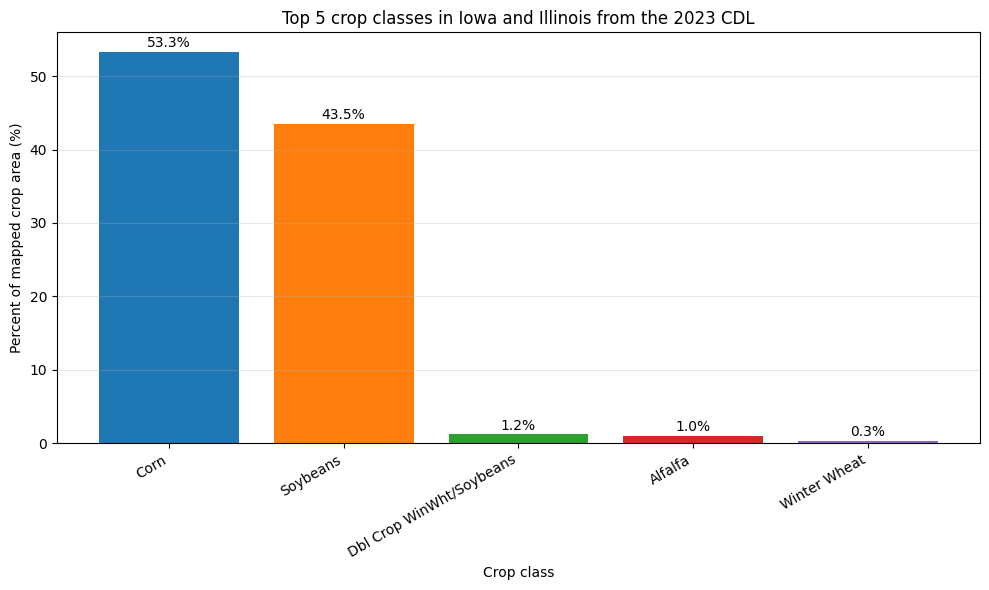

In [44]:
import matplotlib.pyplot as plt

plot_df = top5.copy()

colors = plt.cm.tab10.colors[:len(plot_df)]

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df['class_name'], plot_df['percent_of_crop_area'], color=colors)

plt.xlabel('Crop class')
plt.ylabel('Percent of mapped crop area (%)')
plt.title('Top 5 crop classes in Iowa and Illinois from the 2023 CDL')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add labels above bars
for bar, pct in zip(bars, plot_df['percent_of_crop_area']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()